# Even Split for the Foursquare Dataset

Splits a **preprocessed Foursquare** file into per-client files by distributing
**all meaningful users** evenly across an adjustable number of clients.

There is **no spatial (K-Means) clustering** anymore. Instead, every user that
passes the quality filters (enough check-ins, enough distinct venues, enough
geographic spread) is kept, and the resulting pool is split into `NUM_CLIENTS`
balanced groups via a seeded round-robin assignment.

Paths, encoding and output format follow the conventions of `split_data.py`:
- input  : `data/processed_{dataset}.txt` (tab-separated, no header, ISO-8859-1)
- output : `data/{data_mode}/{dataset}/client{c}_data.txt` (one file per client)

All settings are configured **directly in the notebook** in the next cell.


In [1]:
from google.colab import drive
import os

# Drive mounten
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ✏️ ANPASSEN: Pfad zu deinem Projektordner auf Google Drive
# Beispiel: '/content/drive/MyDrive/FedKG_Project'
project_path = '/content/drive/MyDrive/praktikum/FedKG'


os.chdir(project_path)
print(f"Aktuelles Arbeitsverzeichnis: {os.getcwd()}")

Aktuelles Arbeitsverzeichnis: /content/drive/MyDrive/praktikum/FedKG


## 1. Configuration

Edit these values to control the split.

In [3]:
import os
import math
import random
from collections import defaultdict

# ======================= CONFIGURATION ===================================
DATASET      = "nyc"      # dataset name -> reads data/processed_{DATASET}.txt
DATA_MODE    = "space"  # output goes to data/{DATA_MODE}/{DATASET}/
NUM_CLIENTS  = 5         # number of federated clients to split the users across

# --- Selection / quality-filter parameters ---
NUM_USERS     = None  # optional cap on number of users (None = use ALL eligible users)
MIN_CHECKINS  = 100    # min trajectory length (check-ins per user)
MIN_VENUES    = 20     # min distinct places visited
MIN_SPREAD_KM = 0.0   # min geographic spread (activity radius in km)
SEED          = 42    # random seed for reproducible shuffle / assignment
# =========================================================================

# convenience aliases used below
num_clients = NUM_CLIENTS
dataset     = DATASET
mode        = DATA_MODE

input_path = f"data/processed_{dataset}.txt"
out_dir    = f"data/{mode}/{dataset}"
os.makedirs(out_dir, exist_ok=True)

print(f"dataset      : {dataset}")
print(f"num_clients  : {num_clients}")
print(f"num_users    : {'ALL eligible' if NUM_USERS is None else NUM_USERS}")
print(f"data_mode    : {mode}")
print(f"filters      : >= {MIN_CHECKINS} check-ins, >= {MIN_VENUES} venues, "
      f">= {MIN_SPREAD_KM} km spread")
print(f"input_path   : {input_path}")
print(f"out_dir      : {out_dir}")


dataset      : nyc
num_clients  : 5
num_users    : ALL eligible
data_mode    : space
filters      : >= 100 check-ins, >= 20 venues, >= 0.0 km spread
input_path   : data/processed_nyc.txt
out_dir      : data/space/nyc


## 2. Load rows grouped by user

The preprocessed columns are:
`user_id, venue_id, category_id, category_name, latitude, longitude,
timezone_offset, iso_time` (tab-separated, no header). Rows are kept verbatim so
the per-client output has exactly the same format as the input.


In [4]:
user_rows = defaultdict(list)
with open(input_path, "r", encoding="ISO-8859-1") as f:
    for line in f:
        line = line.rstrip()
        if not line:
            continue
        parts = line.split("\t")
        u_id = int(parts[0])
        user_rows[u_id].append(line)

print(f"Loaded {sum(len(r) for r in user_rows.values()):,} check-ins "
      f"across {len(user_rows)} users (before filtering)")


Loaded 198,250 check-ins across 937 users (before filtering)


## 3. Per-user statistics: length, venue diversity, spatial spread

For every user we compute:
- **n_checkins** - trajectory length
- **n_venues** - number of distinct POIs visited
- **centroid** (mean lat/lon)
- **spread_km** - mean distance of check-ins from the centroid (an "activity
  radius"); small spread means the user basically stays in one place.

Latitude/longitude differences are converted to kilometres with a simple
equirectangular approximation, which is accurate enough at city scale.


In [5]:
def latlon_to_km(dlat, dlon, lat_ref):
    # Equirectangular approximation (good at city scale)
    km_per_deg_lat = 111.0
    km_per_deg_lon = 111.0 * math.cos(math.radians(lat_ref))
    return math.sqrt((dlat * km_per_deg_lat) ** 2 + (dlon * km_per_deg_lon) ** 2)

user_stats = {}
for u_id, rows in user_rows.items():
    lats, lons, venues = [], [], set()
    for row in rows:
        parts = row.split("\t")
        try:
            lats.append(float(parts[4]))
            lons.append(float(parts[5]))
            venues.add(parts[1])
        except (ValueError, IndexError):
            pass
    if not lats:
        continue
    clat = sum(lats) / len(lats)
    clon = sum(lons) / len(lons)
    spread = sum(latlon_to_km(la - clat, lo - clon, clat)
                 for la, lo in zip(lats, lons)) / len(lats)
    user_stats[u_id] = {
        "n_checkins": len(rows),
        "n_venues": len(venues),
        "lat": clat,
        "lon": clon,
        "spread_km": spread,
    }

print(f"Computed stats for {len(user_stats)} users")


Computed stats for 937 users


## 4. Filter to meaningful users

Keep only users that (a) have enough check-ins, (b) visit enough distinct
venues, and (c) actually move around (spread above the threshold). This removes
"home-only / office-only" users and extremely short trajectories.


In [6]:
eligible = [
    u for u, s in user_stats.items()
    if s["n_checkins"] >= MIN_CHECKINS
    and s["n_venues"]   >= MIN_VENUES
    and s["spread_km"]  >= MIN_SPREAD_KM
]

print(f"Eligible users after filtering: {len(eligible)} / {len(user_stats)}")
if NUM_USERS is not None and len(eligible) < NUM_USERS:
    print(f"WARNING: only {len(eligible)} users pass the filters, "
          f"fewer than NUM_USERS={NUM_USERS}. "
          f"Consider relaxing MIN_CHECKINS / MIN_VENUES / MIN_SPREAD_KM.")

Eligible users after filtering: 923 / 937


## 5. Select the users to use

By default **all** eligible users are kept. If `NUM_USERS` is set to an integer,
a reproducible random subset of that size is sampled (using `SEED`); otherwise
the whole eligible pool is used.


In [7]:
random.seed(SEED)
pool = sorted(eligible)                      # deterministic ordering

if NUM_USERS is None:
    selected_users = pool                    # use ALL eligible users
else:
    k = min(NUM_USERS, len(pool))
    selected_users = sorted(random.sample(pool, k))

print(f"Selected {len(selected_users)} users")
print("First few selected ids:", selected_users[:10])

# Quick sanity on the selection's quality
sel_len    = [user_stats[u]["n_checkins"] for u in selected_users]
sel_spread = [user_stats[u]["spread_km"]  for u in selected_users]
print(f"Selected trajectory length  -> mean {sum(sel_len)/len(sel_len):.1f}, "
      f"min {min(sel_len)}, max {max(sel_len)}")
print(f"Selected spatial spread (km) -> mean {sum(sel_spread)/len(sel_spread):.2f}, "
      f"min {min(sel_spread):.2f}, max {max(sel_spread):.2f}")


Selected 923 users
First few selected ids: [1, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Selected trajectory length  -> mean 211.5, min 100, max 2697
Selected spatial spread (km) -> mean 4.43, min 0.25, max 15.01


## 6. Even assignment to clients

Distribute the selected users **evenly** across `num_clients` clients. The users
are shuffled with the fixed `SEED` and then assigned round-robin, so every
client gets (almost) the same number of users and the split is reproducible.
No geographic information is used here.


In [8]:
users = selected_users
user_lat = {u: user_stats[u]["lat"] for u in users}
user_lon = {u: user_stats[u]["lon"] for u in users}

# Shuffle reproducibly, then assign round-robin -> balanced client sizes.
rng = random.Random(SEED)
shuffled = users[:]
rng.shuffle(shuffled)
user_client = {u: i % num_clients for i, u in enumerate(shuffled)}

print(f"Evenly split {len(users)} users across {num_clients} clients "
      f"(round-robin)")


Evenly split 923 users across 5 clients (round-robin)


## 7. Write one file per client

Only rows of the selected users are written. Format and encoding are identical
to the input.


In [9]:
client_files = {c: [] for c in range(num_clients)}
for u_id in selected_users:
    client_files[user_client[u_id]].extend(user_rows[u_id])

for c_id in range(num_clients):
    out_path = f"{out_dir}/client{c_id}_data.txt"
    rows = client_files[c_id]
    with open(out_path, "w", encoding="ISO-8859-1") as f:
        f.write("\n".join(rows) + "\n")
    n_users = sum(1 for u in selected_users if user_client[u] == c_id)
    print(f"client{c_id}: {n_users} users, {len(rows)} rows -> {out_path}")

print("Done.")


client0: 185 users, 38540 rows -> data/space/nyc/client0_data.txt
client1: 185 users, 38340 rows -> data/space/nyc/client1_data.txt
client2: 185 users, 41224 rows -> data/space/nyc/client2_data.txt
client3: 184 users, 37536 rows -> data/space/nyc/client3_data.txt
client4: 184 users, 39571 rows -> data/space/nyc/client4_data.txt
Done.


## 8. Optional: visualize the spatial partition

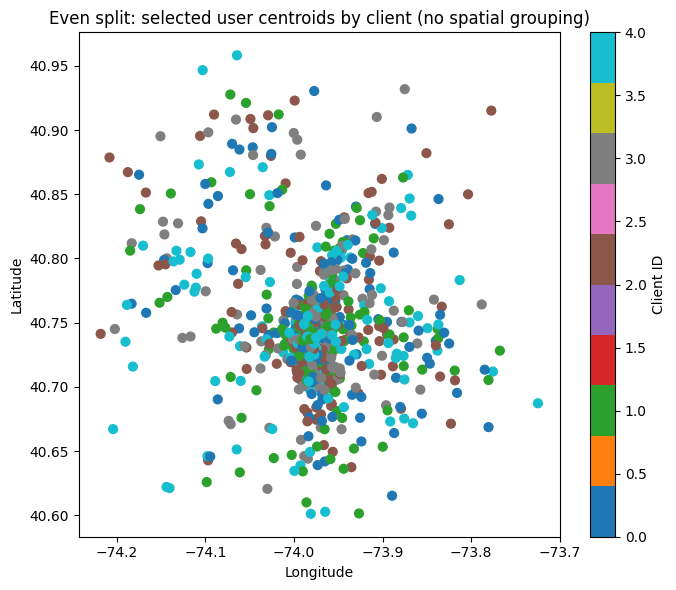

In [10]:
try:
    import matplotlib.pyplot as plt
    lons = [user_lon[u] for u in users]
    lats = [user_lat[u] for u in users]
    cols = [user_client[u] for u in users]
    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(lons, lats, c=cols, cmap="tab10", s=40)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title("Even split: selected user centroids by client (no spatial grouping)")
    plt.colorbar(sc, label="Client ID")
    plt.tight_layout(); plt.show()
except ImportError:
    print("matplotlib not available - skipping plot")
